# LOH.3 - Green's functions and manual convolution

This notebook opens up what `ShakerMaker.run()` does internally, on the SCEC
**LOH.3** model (LOH.1 plus anelastic attenuation) with three surface receivers
at `(8,8)`, `(6,8)` and `(4,4)` km. It is the LOH.1 Green's-function notebook
with `Q` switched on, so the two can be read side by side.

We:

1. build the LOH.3 crust + a Gaussian double-couple source,
2. run the engine with `save_gf=True` so each station keeps its **Green's
   functions**,
3. read the **nine elementary Green's functions** (the `tdata` tensor) and the
   recombined `(Z, E, N)` impulse response,
4. reproduce the seismogram **by hand**, convolving the impulse response with
   the source time function (exactly what `run()` does internally),
5. check that the manual convolution matches `get_response()`, and
6. isolate **what attenuation did to the Green's function itself**, by running
   the identical model with `Q = 10000` and taking the spectral ratio.

Every figure is saved as a `.png` in this folder.

Run against this working tree, not whatever snapshot happens to be installed.
ShakerMaker is installed **non-editable** in some environments (the `clark_kent`
venv carries a frozen copy under `site-packages`), so a plain
`import shakermaker` from this folder picks up that copy instead.

In [1]:
import os
import sys

_REPO = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if _REPO not in sys.path:
    sys.path.insert(0, _REPO)

import numpy as np
import matplotlib.pyplot as plt

import shakermaker as _shakermaker_pkg
from shakermaker import shakermaker
from shakermaker.crustmodel import CrustModel
from shakermaker.pointsource import PointSource
from shakermaker.faultsource import FaultSource
from shakermaker.station import Station
from shakermaker.stationlist import StationList
from shakermaker.stf_extensions.gaussian import Gaussian

print("shakermaker package:", _shakermaker_pkg.__file__)


    ▄████████     ▄█    █▄     ▄████████     ▄█   ▄█▄    ▄████████    ▄████████
    ███    ███   ███    ███    ███    ███    ███ ▄███▀   ███    ███   ███    ███
    ███    █▀    ███    ███    ███    ███    ███▐██▀     ███    █▀    ███    ███
    ███         ▄███▄▄▄▄███▄▄  ███    ███   ▄█████▀     ▄███▄▄▄      ▄███▄▄▄▄██▀
  ▀███████████  ▀███▀▀▀▀███▀  ▀███████████  ▀█████▄    ▀▀███▀▀▀     ▀▀███▀▀▀▀▀
           ███   ███    ███    ███    ███    ███▐██▄     ███    █▄   ▀███████████
     ▄█    ███   ███    ███    ███    ███    ███ ▀███▄   ███    ███   ███    ███
   ▄████████▀    ███    █▀     ███    █▀     ███   ▀█▀   ██████████   ███    ███
                                                                      ███    ███

         ▄▄▄▄███▄▄▄▄      ▄████████    ▄█   ▄█▄    ▄████████    ▄████████
       ▄██▀▀▀███▀▀▀██▄   ███    ███    ███ ▄███▀   ███    ███   ███    ███
       ███   ███   ███   ███    ███    ███▐██▀     ███    █▀    ███    ███
       ███   ███   ███   ███    ███   ▄█████▀  

## 1. Crust model (SCEC LOH.3)

A 1 km slow layer over a half-space, now dissipative. The benchmark fixes
$Q_S = V_S[\mathrm{m/s}]/50$ and $Q_P = \frac{3}{4}(V_P/V_S)^2 Q_S$, i.e.
$Q_S = 40,\ Q_P = 120$ in the layer and $Q_S = 69.3,\ Q_P = 155.9$ in the
half-space. `add_layer` takes `qp` **before** `qs`.

Crust Model with 2 layers.
 Layer  | Depth  | Thick  | Vp     | Vs     | rho    | Qa     | Qb
       1|    0.00|    1.00|    4.00|    2.00|    2.60|   120.0|    40.0
       2|    1.00|    0.00|    6.00|    3.46|    2.70|   155.9|    69.3



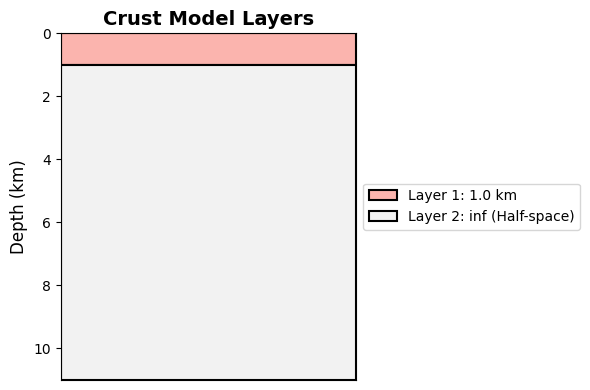

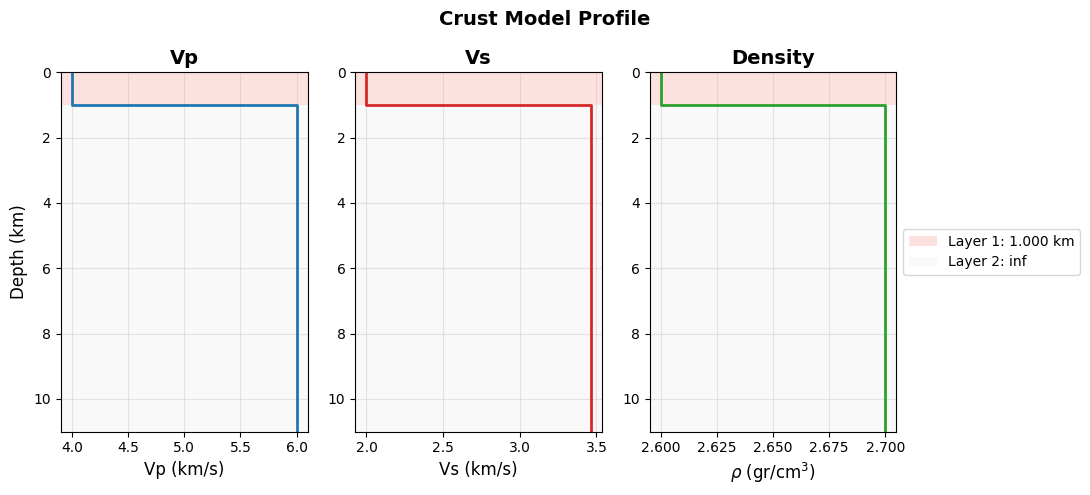

In [2]:
crust = CrustModel(2)
crust.add_layer(1.0, 4.000, 2.000, 2.600, 120.0, 40.0)    # slow layer (1 km)
crust.add_layer(0.0, 6.000, 3.464, 2.700, 155.9, 69.3)    # half-space
print(crust)

crust.plot()
plt.gcf().savefig("loh3_gf_crust_layers.png", dpi=150, bbox_inches="tight")

crust.plot_profile()
plt.gcf().savefig("loh3_gf_velocity_profile.png", dpi=150, bbox_inches="tight")

## 2. Source and source time function

A vertical strike-slip double couple at 2 km depth. The source time function is
a Gaussian with $\sigma = 0.05$ s (LOH.3; LOH.1 uses 0.06 s); its seismic moment
is `M0`.

We keep a **unit** STF (`M0 = 1`) in `stf` for the manual convolution later, and
scale by `M0` separately. Because convolution is linear in the STF,
`stf(M0=1).convolve(...) * M0` is identical to convolving with a Gaussian that
carries `M0` directly - which is what the source uses inside `run()`.

`dt = 0.004` is set by the frequency band, not by the output rate: `fk.f:73`
tapers the spectrum from $0.1 f_{Nyq}$ down to zero at $f_{Nyq}$, so the flat
band is $f \le 0.05/dt = 12.5$ Hz, comfortably above the 3.2 Hz corner of this
Gaussian.

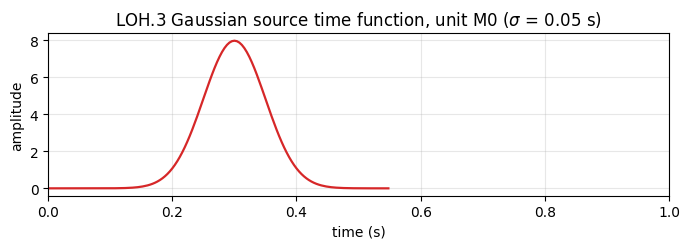

In [3]:
dt = 0.004
sigma = 0.05
t0 = 6 * sigma
M0 = 1e18 / 5e14 / 2

# Source STF (carries M0) used by the engine
source = PointSource([0, 0, 2.0], [0., 90., 0.],
                     stf=Gaussian(t0=t0, freq=1/sigma, M0=M0, derivative=False))
fault = FaultSource([source], metadata={"name": "LOH3_source"})

# Unit STF for the manual convolution (M0 applied separately)
stf = Gaussian(t0=t0, freq=1/sigma, M0=1, derivative=False)
stf.dt = dt
t_stf = stf.t
gauss_SM = stf.data

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(t_stf, gauss_SM, color="tab:red", lw=1.6)
ax.set_xlabel("time (s)"); ax.set_ylabel("amplitude")
ax.set_title(r"LOH.3 Gaussian source time function, unit M0 ($\sigma$ = 0.05 s)")
ax.set_xlim(0, 1.0); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("loh3_stf.png", dpi=150, bbox_inches="tight")

## 3. Stations

Three surface receivers. `save_gf=True` tells the engine to keep each station's
Green's functions in memory (off by default). S2 at `(6,8,0)` is the benchmark
receiver used in `LOH3_validation.ipynb`.

In [4]:
s1 = Station([8.0, 8.0, 0.0], metadata={"name": "sta01", "save_gf": True})
s2 = Station([6.0, 8.0, 0.0], metadata={"name": "sta02", "save_gf": True})
s3 = Station([4.0, 4.0, 0.5], metadata={"name": "sta03", "save_gf": True})
stations = StationList([s1, s2, s3], {})

## 4. Run

`check_parameters` reports the derived FK numbers first (pure arithmetic, no FK
run), then we run the three pairs.

In [5]:
nfft, tb, dk, tmax = 8192, 250, 0.05, 16.0

model = shakermaker.ShakerMaker(crust, fault, stations)
model.check_parameters(dt=dt, nfft=nfft, dk=dk, tb=tb, tmax=tmax)
model.run(dt=dt, nfft=nfft, tb=tb, dk=dk, tmax=tmax, smth=1)

 ShakerMaker . PARAMETER CHECK            you set:  dt + tmax
 YOU CHOSE     dt = 0.004 s        tmax = 16.0 s
 GEOMETRY      r_max 11.3 km . src-rcv sep 1.5-2.0 km . Vs_min 2000 m/s
               Vp_max 6000 m/s . V_Ray 1.84 km/s
               physical signal window  t = [1.0, 16.1] s  (lasts 15.2 s)
----------------------------------------------------------------------
 dt = 0.004 s   sets your FREQUENCY BAND                       [info]
   f_Nyq         = 1/(2*dt)                   = 125 Hz       [fk.f:72]
   f_max usable  = (1-taper)*f_Nyq, taper=0.9 = 12 Hz        [fk.f:74]
   above 12 Hz   fades out smoothly, fully gone by 125 Hz    [fk.f:169]
   lambda_min    = Vs_min/f_max               = 2000/12 = 160.0 m
     element size (N=10 pts/wavelength), for YOUR mesh:
        dx <= lambda_min/N    = 160.0/10 = 16.00 m
        dt <= C*dx/Vp_surf    = 1*16.00/4000 = 0.0040 s
        (Vp_surf = Vp of the soft Vs_min layer, NOT Vp_max:
         the 16.0 m elements live in the soft surfa

1 of 3 done  ETA=0:00:02.8  t=[0.8621, 66.3941] (tmin=0.0000 tmax=16.0000)


2 of 3 done  ETA=0:00:00.0  t=[0.0518, 65.5838] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 7.70 s
--------------------------------------------------


## 5. Station responses (velocity)

`get_response()` returns the three-component velocity `(Z, E, N)` and the time
vector. Rows are components, columns are the three stations.

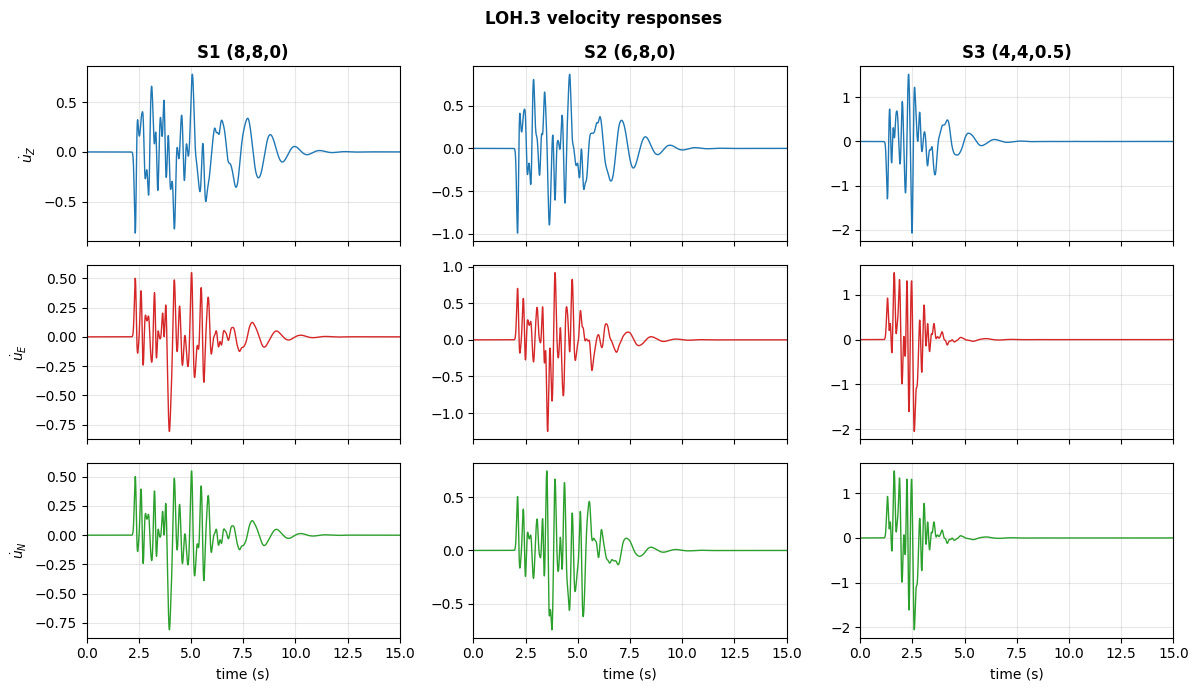

In [6]:
resp = {
    "S1 (8,8,0)": s1.get_response(),
    "S2 (6,8,0)": s2.get_response(),
    "S3 (4,4,0.5)": s3.get_response(),
}

fig, axes = plt.subplots(3, 3, figsize=(12, 7), sharex=True)
comp_colors = {"Z": "tab:blue", "E": "tab:red", "N": "tab:green"}
for col, (name, (z, e, n, t)) in enumerate(resp.items()):
    for row, (lab, data) in enumerate(zip(["Z", "E", "N"], [z, e, n])):
        ax = axes[row, col]
        ax.plot(t, data, color=comp_colors[lab], lw=1.0)
        ax.set_xlim(0, 15); ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(name, fontweight="bold")
        if col == 0:
            ax.set_ylabel(rf"$\dot{{u}}_{lab}$")
for ax in axes[-1, :]:
    ax.set_xlabel("time (s)")
fig.suptitle("LOH.3 velocity responses", fontweight="bold")
fig.tight_layout()
fig.savefig("loh3_responses.png", dpi=150, bbox_inches="tight")

## 6. Green's functions

With `save_gf=True`, each station exposes `get_greens_functions()` -> a dict
keyed by source/subfault index. Each entry is
`(z, e, n, t, tdata, t0)` where:

- `z, e, n` are the **recombined impulse response** in (Z, E, N) for the
  source mechanism (before the source time function and before `M0`),
- `tdata` has shape `(1, 9, nt)`: the **nine elementary Green's functions**
  (Helmberger's DD/DS/SS set) for this source-receiver pair,
- `t0` is the reduction time and `t` the time vector.

These are where the attenuation lives. Everything downstream - the STF, `M0`,
the rotation - is identical to LOH.1.

In [7]:
gf_s1 = s1.get_greens_functions()
gf_s2 = s2.get_greens_functions()
gf_s3 = s3.get_greens_functions()

z, e, n, t, tdata, t0 = gf_s1[0]
print("tdata shape:", tdata.shape, " (1, 9, nt)")
nt = tdata.shape[2]
t_gf = np.arange(nt) * (t[1] - t[0]) + t0

tdata shape: (1, 9, 16384)  (1, 9, nt)


### The nine elementary Green's functions (station S1)

The `tdata` tensor: 9 traces that, recombined with the moment tensor and the
station azimuth, give the (Z, E, N) response.

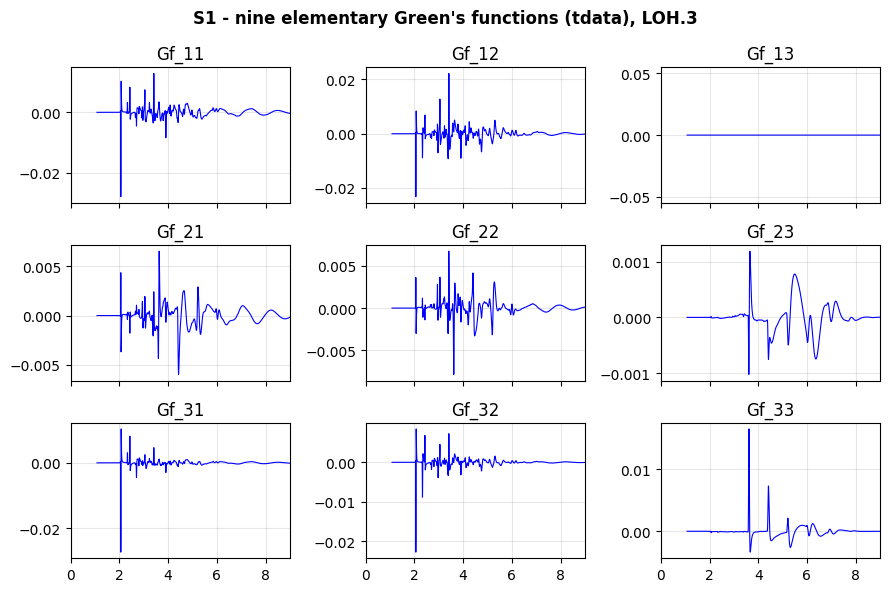

In [8]:
labels = [['Gf_11', 'Gf_12', 'Gf_13'],
          ['Gf_21', 'Gf_22', 'Gf_23'],
          ['Gf_31', 'Gf_32', 'Gf_33']]

fig, axes = plt.subplots(3, 3, figsize=(9, 6), sharex=True)
for i in range(3):
    for j in range(3):
        axes[i, j].plot(t_gf, tdata[0, i*3 + j, :], 'b-', lw=0.8)
        axes[i, j].set_title(labels[i][j])
        axes[i, j].grid(True, alpha=0.3)
        axes[i, j].set_xlim(0, 9)
fig.suptitle("S1 - nine elementary Green's functions (tdata), LOH.3",
             fontweight="bold")
fig.tight_layout()
fig.savefig("loh3_gf_tensor.png", dpi=150, bbox_inches="tight")

### Recombined impulse response (Z, E, N)

The `z, e, n` arrays: the impulse response already recombined for the source
mechanism and rotated to the geographic components - still before the source
time function.

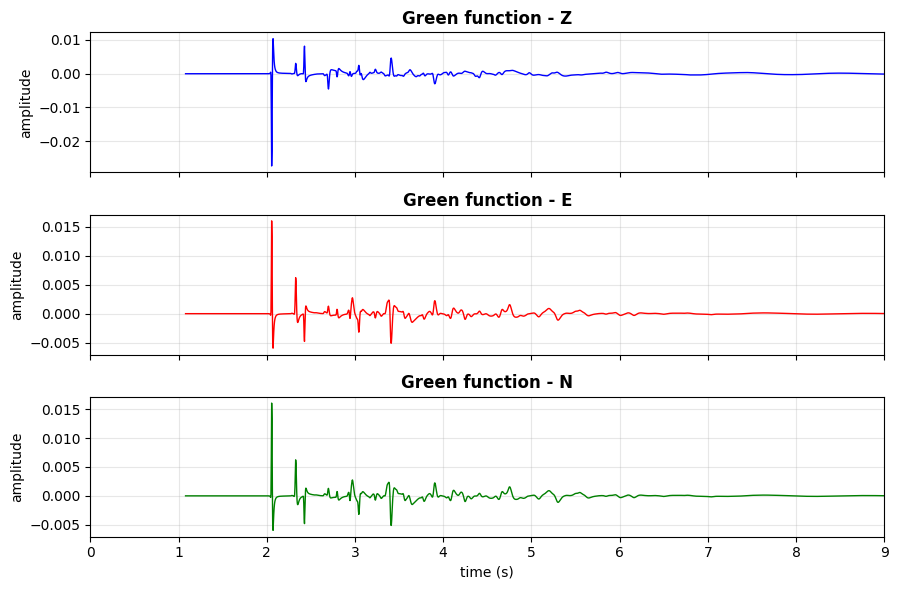

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, data, lab, color in zip(axes, [z, e, n], ['Z', 'E', 'N'], ['b', 'r', 'g']):
    ax.plot(t, data, color=color, lw=1.0)
    ax.set_title(f'Green function - {lab}', fontweight='bold')
    ax.set_ylabel('amplitude')
    ax.set_xlim(0, 9); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time (s)')
fig.tight_layout()
fig.savefig("loh3_gf_components.png", dpi=150, bbox_inches="tight")

## 7. Manual convolution = the seismogram

The seismogram is the impulse response convolved with the source time function
and scaled by the seismic moment. This is exactly what `run()` does internally
(`shakermaker.py`: `z_stf = psource.stf.convolve(z, t)`).

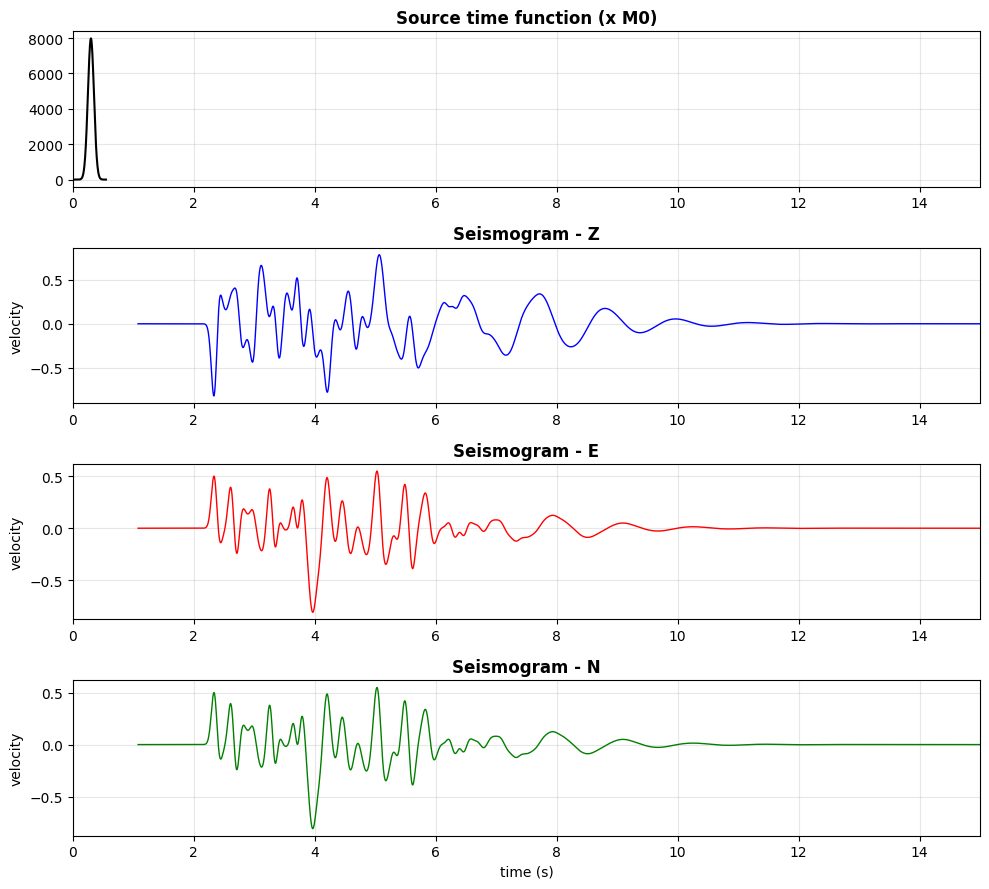

In [10]:
z, e, n, t, tdata, t0 = gf_s1[0]

stf.dt = dt                     # unit Gaussian, sampled at the signal dt
z_stf = stf.convolve(z, t) * M0
e_stf = stf.convolve(e, t) * M0
n_stf = stf.convolve(n, t) * M0

fig, axes = plt.subplots(4, 1, figsize=(10, 9))
axes[0].plot(t_stf, gauss_SM * M0, 'k-', lw=1.5)
axes[0].set_title('Source time function (x M0)', fontweight='bold')
axes[0].set_xlim(0, 15); axes[0].grid(True, alpha=0.3)
for ax, data, lab, color in zip(axes[1:], [z_stf, e_stf, n_stf], ['Z', 'E', 'N'], ['b', 'r', 'g']):
    ax.plot(t, data, color=color, lw=1.0)
    ax.set_title(f'Seismogram - {lab}', fontweight='bold')
    ax.set_ylabel('velocity')
    ax.set_xlim(0, 15); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('time (s)')
fig.tight_layout()
fig.savefig("loh3_seismograms_manual.png", dpi=150, bbox_inches="tight")

## 8. Check: manual convolution == `run()` output

The manual seismogram (impulse response convolved by hand) must match the
station response that `run()` produced. We overlay them for station S1.

Z correlation (manual vs run): 0.9985


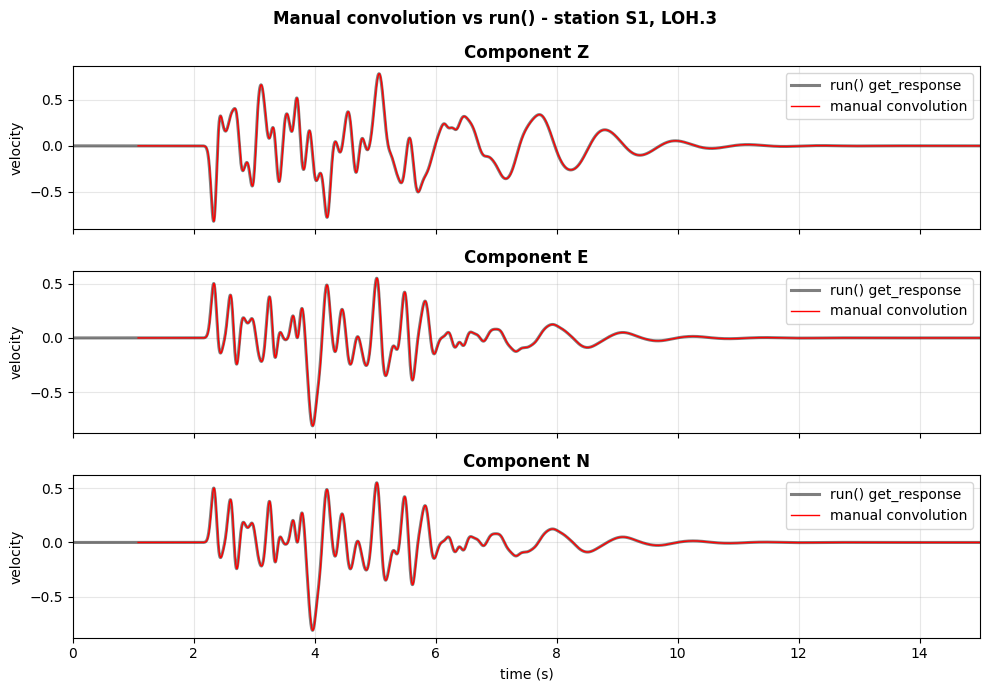

In [11]:
z_v1, e_v1, n_v1, t1 = s1.get_response()

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, manual, run_out, lab in zip(axes, [z_stf, e_stf, n_stf],
                                    [z_v1, e_v1, n_v1], ['Z', 'E', 'N']):
    ax.plot(t1, run_out, 'k-', lw=2.2, alpha=0.5, label='run() get_response')
    ax.plot(t, manual, 'r-', lw=1.0, label='manual convolution')
    ax.set_title(f'Component {lab}', fontweight='bold')
    ax.set_ylabel('velocity'); ax.set_xlim(0, 15); ax.grid(alpha=0.3)
    ax.legend(loc='upper right')
axes[-1].set_xlabel('time (s)')
fig.suptitle('Manual convolution vs run() - station S1, LOH.3', fontweight='bold')
fig.tight_layout()
fig.savefig("loh3_convolution_check.png", dpi=150, bbox_inches="tight")

# numeric check: interpolate run() onto the manual grid and correlate
zi = np.interp(t, t1, z_v1)
mask = (t >= 0) & (t <= 15)
cc = np.corrcoef(zi[mask], z_stf[mask])[0, 1]
print(f"Z correlation (manual vs run): {cc:.4f}")

## 9. What attenuation did to the Green's function

Everything above is LOH.1 with `Q` switched on. To isolate `Q` we run the
**identical** model with `Q = 10000` (the LOH.1 crust) and compare the Green's
functions directly. No source time function, no `M0`, no rotation - just the
impulse response of the medium.

In [12]:
crust_el = CrustModel(2)
crust_el.add_layer(1.0, 4.000, 2.000, 2.600, 10000., 10000.)
crust_el.add_layer(0.0, 6.000, 3.464, 2.700, 10000., 10000.)

s1_el = Station([8.0, 8.0, 0.0], metadata={"name": "sta01_elastic", "save_gf": True})
m_el = shakermaker.ShakerMaker(crust_el,
                               FaultSource([PointSource([0, 0, 2.0], [0., 90., 0.],
                                            stf=Gaussian(t0=t0, freq=1/sigma, M0=M0,
                                                         derivative=False))],
                                           metadata={"name": "LOH1_source"}),
                               StationList([s1_el], {}))
m_el.run(dt=dt, nfft=nfft, tb=tb, dk=dk, tmax=tmax, smth=1)

z_el, e_el, n_el, t_el, tdata_el, t0_el = s1_el.get_greens_functions()[0]
# t0 comes back as a per-distance array; this run has a single distance.
print(f"t0 (reduction time): LOH.3 {float(np.ravel(t0)[0]):.4f} s   "
      f"LOH.1 {float(np.ravel(t0_el)[0]):.4f} s")



ShakerMaker Run begin. dt=0.004 nfft=8192 dk=0.05 tb=250 tmin=0.0 tmax=16.0
---------------------------------------------------------------------------


0 of 1 done  ETA=0:00:00.0  t=[1.0799, 66.6119] (tmin=0.0000 tmax=16.0000)


ShakerMaker run done. Total time: 2.69 s
--------------------------------------------------
t0 (reduction time): LOH.3 1.0799 s   LOH.1 1.0799 s


comp    peak LOH.1   peak LOH.3    ratio
Z          0.15998      0.02732    0.171
E          0.20161      0.01604    0.080
N          0.20161      0.01604    0.080

These ratios are far below the ~0.6 seen on the seismograms: the raw
impulse response carries the whole 12.5 Hz band, while the sigma = 0.05 s
Gaussian keeps only what is below ~8 Hz, and exp(-pi f t*) punishes the
difference.


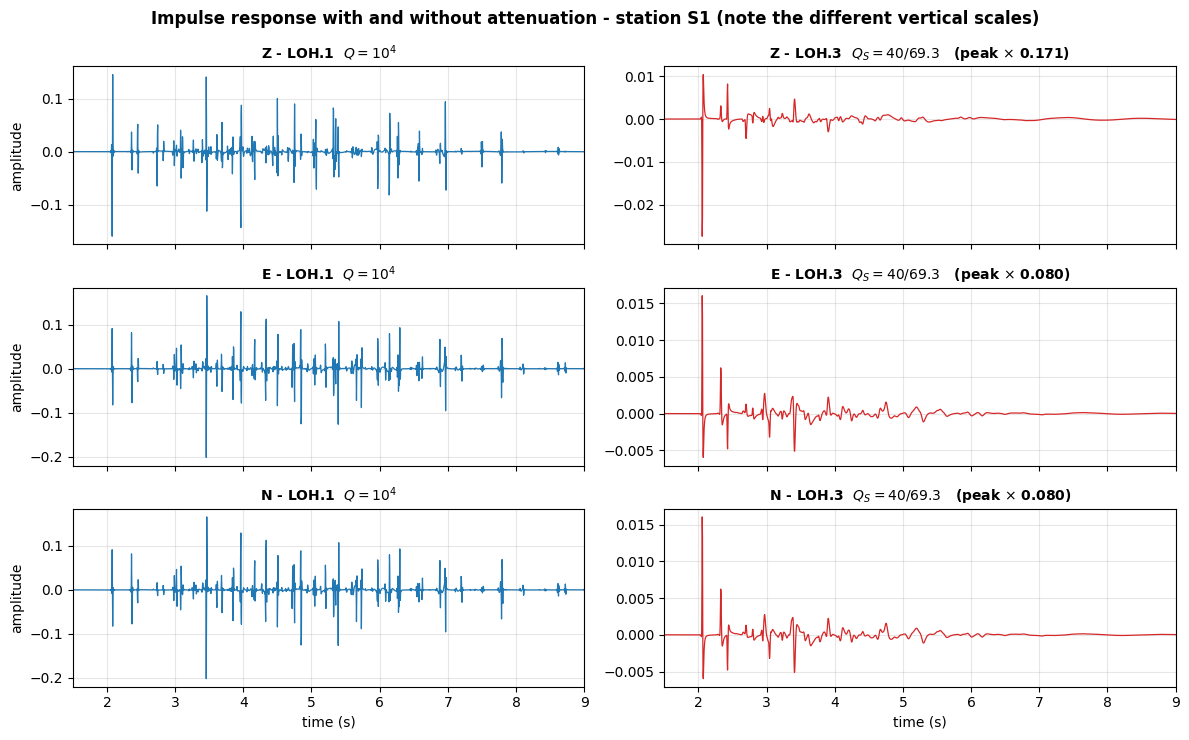

In [13]:
# Plotted on a shared y-axis the attenuated Green's function is invisible: these
# are raw impulse responses, so they carry the full 12.5 Hz band and Q bites
# hardest exactly there. One column per model, each auto-scaled, keeps both
# readable; the peak ratio is in the title so the scale difference is not lost.
fig, axes = plt.subplots(3, 2, figsize=(12, 7.5), sharex=True)
for row, (a, b, lab) in enumerate(zip([z_el, e_el, n_el], [z, e, n], ['Z', 'E', 'N'])):
    ratio = np.abs(b).max() / np.abs(a).max()
    axes[row, 0].plot(t_el, a, color="tab:blue", lw=0.9)
    axes[row, 0].set_title(rf"{lab} - LOH.1  $Q = 10^4$", fontweight="bold",
                           fontsize=10)
    axes[row, 1].plot(t, b, color="tab:red", lw=0.9)
    axes[row, 1].set_title(rf"{lab} - LOH.3  $Q_S = 40/69.3$   "
                           rf"(peak $\times$ {ratio:.3f})",
                           fontweight="bold", fontsize=10)
    for col in (0, 1):
        axes[row, col].set_xlim(1.5, 9)
        axes[row, col].grid(alpha=0.3)
    axes[row, 0].set_ylabel("amplitude")
for col in (0, 1):
    axes[-1, col].set_xlabel("time (s)")
fig.suptitle("Impulse response with and without attenuation - station S1 "
             "(note the different vertical scales)", fontweight="bold")
fig.tight_layout()
fig.savefig("loh3_gf_vs_loh1.png", dpi=150, bbox_inches="tight")

print(f"{'comp':5s} {'peak LOH.1':>12s} {'peak LOH.3':>12s} {'ratio':>8s}")
for a, b, lab in zip([z_el, e_el, n_el], [z, e, n], ['Z', 'E', 'N']):
    print(f"{lab:5s} {np.abs(a).max():12.5f} {np.abs(b).max():12.5f} "
          f"{np.abs(b).max()/np.abs(a).max():8.3f}")
print("\nThese ratios are far below the ~0.6 seen on the seismograms: the raw\n"
      "impulse response carries the whole 12.5 Hz band, while the sigma = 0.05 s\n"
      "Gaussian keeps only what is below ~8 Hz, and exp(-pi f t*) punishes the\n"
      "difference.")

### Control: the same nine Green's functions, without Q

The `tdata` figure above is produced by **byte-identical** plotting code to
`LOH1_greens_functions.ipynb`, on the same `tdata[0, i*3+j, :]` array. It still
looks different from the LOH.1 one, for two separate reasons, and it is worth
being explicit about which is which.

1. **Q, the physical one.** Attenuation wipes out the later multiples and
   low-passes every arrival by $e^{-\pi f t^*}$, so the picket fence of sharp
   spikes becomes a few rounded pulses followed by a smooth tail. That smooth
   tail is what makes it *look* like a velocity seismogram rather than an
   impulse response - but nothing was convolved: this is still the raw Green's
   function.
2. **Different FK parameters between the two notebooks**, which change the
   picture without changing the physics:
   - `LOH1_greens_functions.ipynb` uses `dt=0.005, nfft=4096, tb=20, dk=0.025`;
     this one uses `dt=0.004, nfft=8192, tb=250, dk=0.05`.
   - `tb` is the pre-arrival padding **in samples**, so LOH.1 pads 0.1 s and
     this notebook pads 1.0 s. The reduction time `t0` moves accordingly and the
     trace starts at ~2.0 s there and ~1.08 s here. `check_parameters` flags
     `tb=20` as below its sane range (>=250), which is why this notebook does
     not copy it.
   - An impulse response is a distribution: the height of a delta-like arrival
     scales as `1/dt`. Amplitudes are therefore **not** comparable across the
     two notebooks, only within one.

The control below removes reason 1 and leaves reason 2: the identical code and
identical FK parameters, with `Q = 10000`. If it comes out as a picket fence,
then the smooth look of the LOH.3 tensor is attenuation and nothing else.

component     centroid elastic   centroid LOH.3    shift
Gf_11                   6.92 Hz           4.84 Hz     0.70
Gf_22                   7.68 Hz           4.99 Hz     0.65
Gf_33                   7.11 Hz           4.95 Hz     0.70

The attenuated Green's functions carry their energy at 0.65-0.70 of the
elastic centre frequency, ~7 Hz -> ~5 Hz. That is the low-pass that turns
a picket fence into something that looks like a waveform - no convolution
involved.


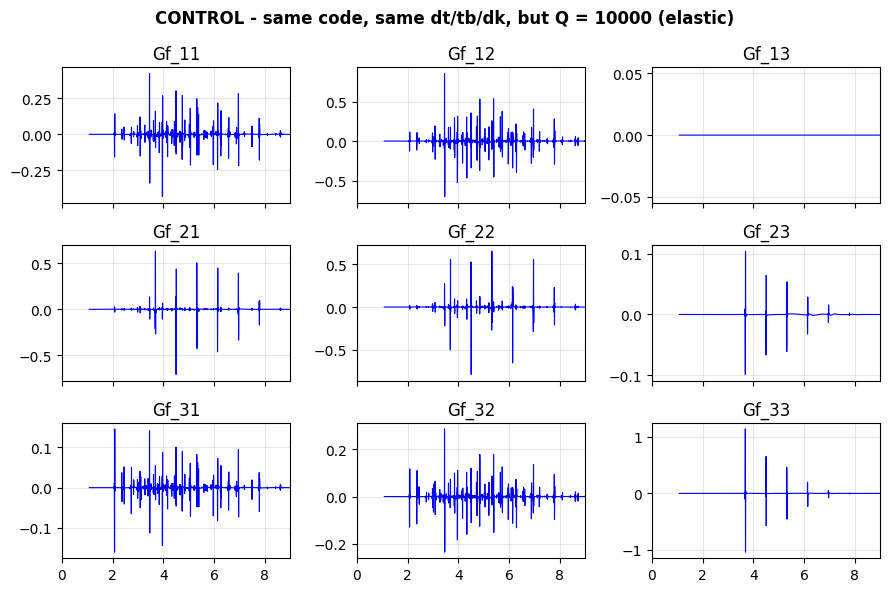

In [14]:
nt_el = tdata_el.shape[2]
t_gf_el = np.arange(nt_el) * (t_el[1] - t_el[0]) + np.ravel(t0_el)[0]

fig, axes = plt.subplots(3, 3, figsize=(9, 6), sharex=True)
for i in range(3):
    for j in range(3):
        axes[i, j].plot(t_gf_el, tdata_el[0, i*3 + j, :], 'b-', lw=0.8)
        axes[i, j].set_title(labels[i][j])
        axes[i, j].grid(True, alpha=0.3)
        axes[i, j].set_xlim(0, 9)
fig.suptitle("CONTROL - same code, same dt/tb/dk, but Q = 10000 (elastic)",
             fontweight="bold")
fig.tight_layout()
fig.savefig("loh3_gf_tensor_elastic.png", dpi=150, bbox_inches="tight")

# Quantify "smoother" properly. Peak-to-RMS will not do it: attenuation can
# *raise* it by killing every arrival except the first. The spectral centroid,
# sum(f|X|)/sum(|X|), measures where the energy sits in frequency, which is
# exactly what a low-pass moves.
def centroid(x, dt_):
    X = np.abs(np.fft.rfft(x * np.hanning(len(x))))
    fq = np.fft.rfftfreq(len(x), d=dt_)
    m = (fq > 0.2) & (fq < 12.0)
    return float((fq[m] * X[m]).sum() / X[m].sum())


w = (t_gf >= 2) & (t_gf <= 9)
w_el = (t_gf_el >= 2) & (t_gf_el <= 9)
print(f"{'component':11s} {'centroid elastic':>18s} {'centroid LOH.3':>16s} "
      f"{'shift':>8s}")
for lab, idx in [("Gf_11", 0), ("Gf_22", 4), ("Gf_33", 8)]:
    ca = centroid(tdata_el[0, idx, :][w_el], t_el[1] - t_el[0])
    cb = centroid(tdata[0, idx, :][w], t[1] - t[0])
    print(f"{lab:11s} {ca:16.2f} Hz {cb:14.2f} Hz {cb/ca:8.2f}")
print("\nThe attenuated Green's functions carry their energy at 0.65-0.70 of the\n"
      "elastic centre frequency, ~7 Hz -> ~5 Hz. That is the low-pass that turns\n"
      "a picket fence into something that looks like a waveform - no convolution\n"
      "involved.")

### The spectral ratio: reading $t^*$ off the Green's functions

Constant-$Q$ attenuation multiplies the spectrum by $e^{-\pi f t^*}$ with
$t^* = \int \mathrm{d}s / (V Q)$ along the path. So

$$ \ln \frac{|G_{LOH.3}(f)|}{|G_{LOH.1}(f)|} = -\pi t^* f $$

should be a **straight line through the origin**, and its slope gives $t^*$.
That is a direct test of the attenuation operator, independent of the reference
solution.

The measured ratio does *not* come out clean: wherever the elastic Green's
function has a spectral null - and at 10 km, with direct, refracted and
reflected arrivals interfering, it has many - the quotient spikes. The trend is
unambiguous, but the scatter is large, so we fit the ratio of the **smoothed**
amplitude spectra and show the raw one underneath for honesty.

The straight-ray estimate below is only an order-of-magnitude bracket: the real
wavefield at 10 km is a sum of direct, refracted and reflected arrivals with
different paths and therefore different $t^*$, so a single slope is an
effective average, not a quantity the straight ray predicts exactly.

measured  t* =   71.0 ms   (smoothed, slope -0.2230 per Hz)
          t* =   72.5 ms   (raw, unsmoothed)
straight-ray bracket t* =   95.7 ms  (ray length 11.49 km, half in the layer)


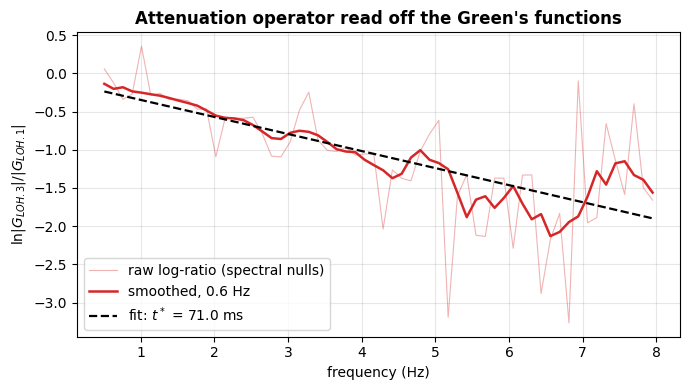

In [15]:
# Both runs used the same dt/nfft/tb/tmax, so the two Green's functions live on
# the same time grid - assert it rather than interpolate and blur the spectra.
assert np.allclose(t, t_el), "LOH.1 and LOH.3 Green's functions are not on the same grid"

win = (t >= 0) & (t <= 9)
a = n_el[win]          # elastic
b = n[win]             # attenuated
w = np.hanning(len(a))
A = np.fft.rfft(a * w)
B = np.fft.rfft(b * w)
f = np.fft.rfftfreq(len(a), d=dt)

def smooth(x, freq, width=0.6):
    """Running mean over a +-width/2 Hz window.

    The raw ratio is spiky: wherever the elastic Green's function has a
    spectral null (interference between the direct, refracted and reflected
    arrivals) the quotient blows up. Smoothing both amplitude spectra over a
    band wider than the null spacing leaves the decay trend intact.
    """
    return np.array([x[np.abs(freq - fi) <= width / 2].mean() for fi in freq])


band = (f > 0.5) & (f < 8.0)
ratio_raw = np.log(np.abs(B[band]) / np.abs(A[band]))
ratio = np.log(smooth(np.abs(B), f)[band] / smooth(np.abs(A), f)[band])

slope, intercept = np.polyfit(f[band], ratio, 1)
tstar = -slope / np.pi
slope_raw = np.polyfit(f[band], ratio_raw, 1)[0]
tstar_raw = -slope_raw / np.pi

# straight-ray bracket, source (0,0,2) -> receiver (8,8,0)
L = np.sqrt(8.0**2 + 8.0**2 + 2.0**2)
frac_layer = 1.0 / 2.0          # z goes 2 -> 0, so z < 1 over half the ray
tstar_ray = (L * frac_layer) / (2.000 * 40.0) + (L * (1 - frac_layer)) / (3.464 * 69.3)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(f[band], ratio_raw, color="tab:red", lw=0.8, alpha=0.35,
        label="raw log-ratio (spectral nulls)")
ax.plot(f[band], ratio, color="tab:red", lw=1.8, label="smoothed, 0.6 Hz")
ax.plot(f[band], slope * f[band] + intercept, "k--", lw=1.6,
        label=rf"fit: $t^*$ = {tstar*1000:.1f} ms")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"$\ln |G_{LOH.3}| / |G_{LOH.1}|$")
ax.set_title(r"Attenuation operator read off the Green's functions",
             fontweight="bold")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("loh3_tstar.png", dpi=150, bbox_inches="tight")

print(f"measured  t* = {tstar*1000:6.1f} ms   (smoothed, slope {slope:.4f} per Hz)")
print(f"          t* = {tstar_raw*1000:6.1f} ms   (raw, unsmoothed)")
print(f"straight-ray bracket t* = {tstar_ray*1000:6.1f} ms  "
      f"(ray length {L:.2f} km, half in the layer)")

## Checkpoint

You have taken LOH.3 apart the same way as LOH.1: the nine elementary Green's
functions, the recombined impulse response, and the seismogram rebuilt by hand
from them. The manual convolution reproduces `run()`, and the LOH.1/LOH.3
spectral ratio decays linearly in $f$ - the signature of a constant-$Q$
operator - with an effective $t^*$ of the order the ray geometry implies.

For the comparison against the published reference solution - and for the
$Q$ reference-frequency subtlety that caps it at correlation 0.95 if you ignore
it - see `LOH3_validation.ipynb`.